# <font color='#F5B167'> MD009 Ejemplo algoritmo de Metropolis-Hastings </font>

Es un algoritmo de tipo Markov Chain Monte Carlo (MCMC), pues genera valores aleatorios que siguen una cierta distribución de probabilidad, de manera que para generar un nuevo valor, solo tiene en cuenta el valor actual.

En este ejemplo, generamos dos variables, (x,y), distribuidas según un "círculo", centrado en el punto (1, 2) y de radio 3. Es decir, generaremos conforme la función $f(x, y)=-(x-1)^2-(y-2)^2+3^2$. No importa si no está normalizada, pues durante la generación solo usaremos cocientes.
Empezando en el punto (0,0) proponemos cambios en $x$ e $y$ a partir de una distribución normal, tal que los aceptamos si el valor de $f(x,y)$ para los nuevos valores $(x^*, y^*)$ es mayor que antes, o si no lo es, lo aceptamos con una probabilidad $f(x^*,y^*)/f(x,y)$.

In [1]:
circle <- function(x,y){ #definimos la función del círculo
    value = -(x-1)^2-(y-2)^2+9
    return(value)
}

#inicializamos los valores

x = 0
y = 0

target_x <- 0
target_y <- 0

N = 10000
k = 1
while(k <= N){
    x_star = x + rnorm(1, 0, 1) #generamos los nuevos valores x* e y*
    y_star = y + rnorm(1, 0, 1)
    
    if(runif(1,0,1) < circle(x_star, y_star)/circle(x,y)){ #definimos la probabilidad con la que se aceptarán los nuevos valores
        x = x_star
        y = y_star
        target_x[k] <- x
        target_y[k] <- y
        k = k + 1    
    }
          
}

Veamos qué pinta tienen los valores generados.

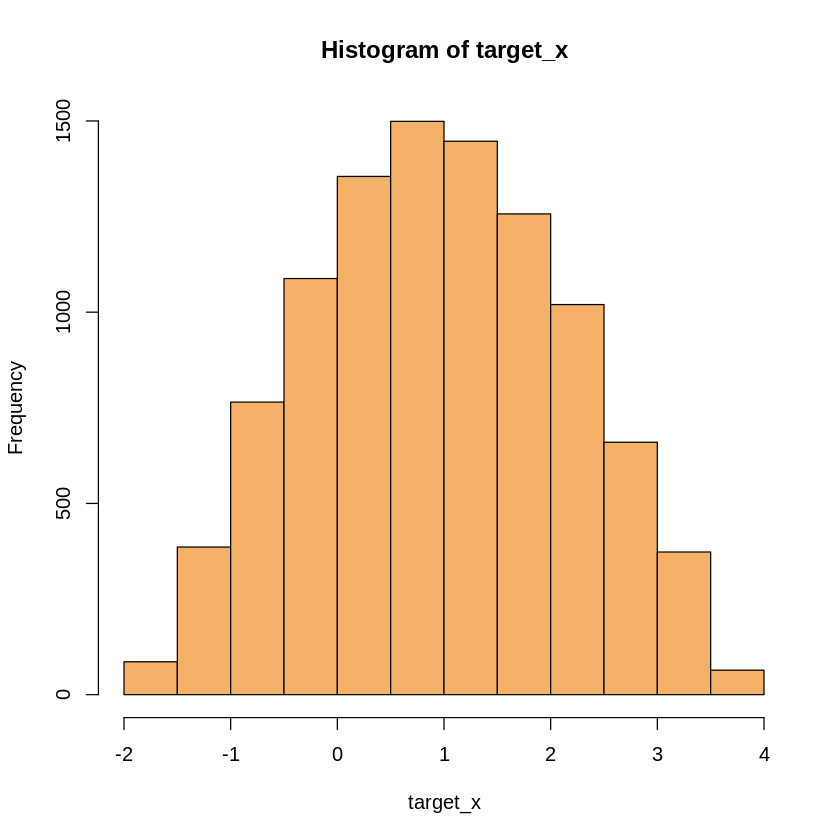

In [2]:
hist(target_x, col = '#F5B167')

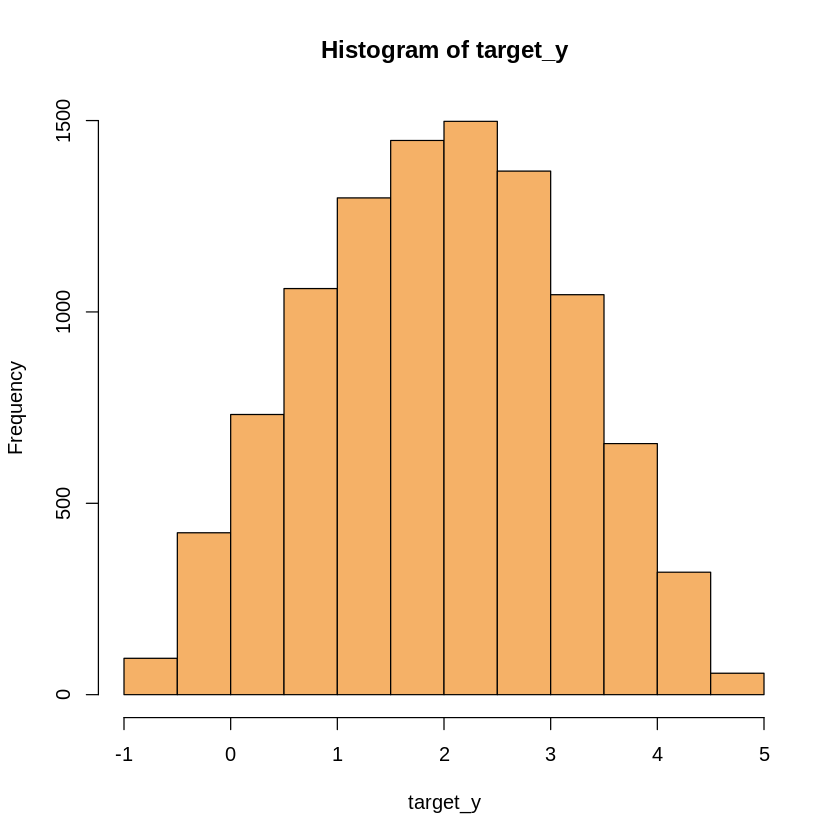

In [3]:
hist(target_y, col = '#F5B167')


----------------------------
2-D Histogram Object
----------------------------

Call: hist2d(x = target_x, y = target_y, nbins = 25, col = r, xlab = "x", 
    ylab = "y")

Number of data points:  10000 
Number of grid bins:  25 x 25 
X range: ( -1.945366 , 3.900285 )
Y range: ( -0.9619391 , 4.890335 )


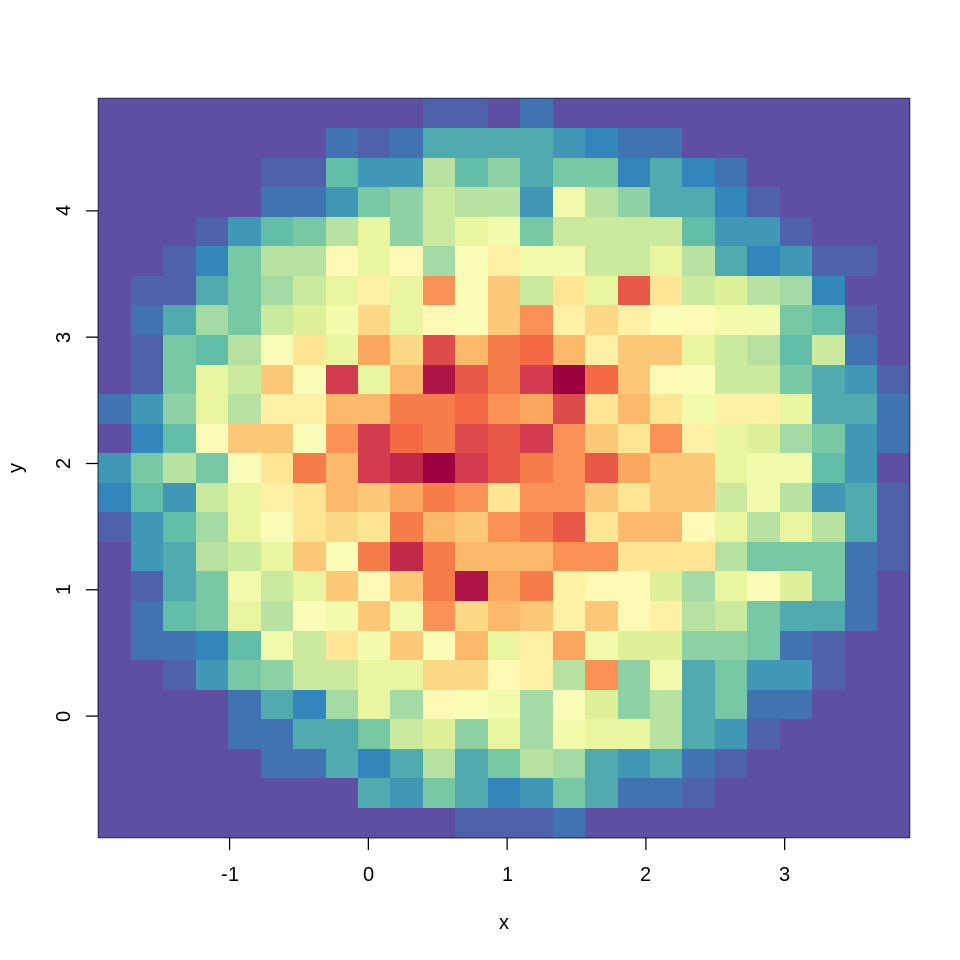

In [6]:
#install.packages('gplots')
library(gplots)
library(RColorBrewer)
rf <- colorRampPalette(rev(brewer.pal(11,'Spectral')))
r <- rf(32)
options(repr.plot.width = 8, repr.plot.height = 8)
hist2d(target_x, target_y, nbins = 25, col = r, xlab = 'x', ylab = 'y')